In [1]:
!pip install transformers accelerate datasets numpy --upgrade
!pip install einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import json

# Set your input/output path
base_path = "/content/drive/MyDrive/nvd"
output_path = os.path.join(base_path, "cleaned")
os.makedirs(output_path, exist_ok=True)

# Process files from 2002 to 2024
for year in range(2015, 2025):
    input_file = os.path.join(base_path, f"nvdcve-1.1-{year}.json")
    output_file = os.path.join(output_path, f"nvdcve-cleaned-{year}.json")

    if not os.path.exists(input_file):
        print(f"File not found: {input_file}. Skipping.")
        continue

    with open(input_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    original_count = len(data.get("CVE_Items", []))
    cleaned_items = []

    for item in data["CVE_Items"]:
        descriptions = item["cve"]["description"]["description_data"]
        if any("Rejected reason" in desc["value"] for desc in descriptions):
            continue
        cleaned_items.append(item)

    data["CVE_Items"] = cleaned_items

    with open(output_file, "w", encoding="utf-8") as f_out:
        json.dump(data, f_out, indent=2)

    print(f"{year}: {original_count} -> {len(cleaned_items)} saved to {output_file}")

2015: 1570 -> 902 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2015.json
2016: 2471 -> 1193 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2016.json
2017: 6201 -> 3859 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2017.json
2018: 17489 -> 15861 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2018.json
2019: 17030 -> 15554 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2019.json
2020: 20600 -> 18970 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2020.json
2021: 23070 -> 22249 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2021.json
2022: 26408 -> 25372 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2022.json
2023: 29722 -> 29165 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2023.json
2024: 38257 -> 37588 saved to /content/drive/MyDrive/nvd/cleaned/nvdcve-cleaned-2024.json


In [ ]:
import os
import json

input_dir = "/content/drive/MyDrive/nvd/cleaned"
output_file = "/content/drive/MyDrive/nvd/github_links_2015_2024.json"

results = []

for year in range(2015, 2025):
    input_path = os.path.join(input_dir, f"nvdcve-cleaned-{year}.json")
    if not os.path.exists(input_path):
        print(f"{year} file not found. Skipping.")
        continue

    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data.get("CVE_Items", []):
        cve_id = item["cve"]["CVE_data_meta"]["ID"]
        refs = item["cve"].get("references", {}).get("reference_data", [])
        github_links = [
            ref["url"]
            for ref in refs
            if "github.com" in ref.get("url", "").lower()
        ]
        if github_links:
            results.append({
                "cve_id": cve_id,
                "github_links": github_links
            })

print(f"Extracted {len(results)} CVEs with GitHub links.")
with open(output_file, "w", encoding="utf-8") as f_out:
    json.dump(results, f_out, indent=2)
print(f"Saved to {output_file}")

Extracted 42186 CVEs with GitHub links.
Saved to /content/drive/MyDrive/nvd/github_links_2015_2024.json


In [ ]:
import json
import os
import requests
from urllib.parse import urlparse

# === 路径设置 ===
json_file = "/content/drive/MyDrive/nvd/github_links_2015_2024.json"
output_dir = "patches"
os.makedirs(output_dir, exist_ok=True)

# === 读取 JSON 文件 ===
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# === 提取并过滤 commit 链接 ===
def is_valid_commit_link(url):
    return "github.com" in url and "/commit/" in url

# === 抓取 patch 内容 ===
def download_patch(cve_id, url, index):
    try:
        # 清洗链接：移除 fragment
        clean_url = url.split("#")[0]
        patch_url = clean_url + ".patch"
        response = requests.get(patch_url, timeout=10)
        if response.status_code == 200:
            filename = f"{cve_id.replace(':', '-')}_{index}.patch"
            filepath = os.path.join(output_dir, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(response.text)
            print(f"Saved: {filename}")
        else:
            print(f"Failed: {patch_url} (status: {response.status_code})")
    except Exception as e:
        print(f"Error downloading {url}: {e}")

# === 主程序 ===
for entry in data:
    cve_id = entry["cve_id"]
    links = entry["github_links"]
    for i, link in enumerate(links):
        if is_valid_commit_link(link):
            download_patch(cve_id, link, i)

流式输出内容被截断，只能显示最后 5000 行内容。
Saved: CVE-2023-4897_1.patch
Saved: CVE-2023-4898_0.patch
Saved: CVE-2023-4898_1.patch
Saved: CVE-2023-4899_0.patch
Saved: CVE-2023-4899_1.patch
Saved: CVE-2023-49006_2.patch
Saved: CVE-2023-49006_3.patch
Saved: CVE-2023-49062_0.patch
Saved: CVE-2023-49062_1.patch
Saved: CVE-2023-49075_0.patch
Saved: CVE-2023-49075_1.patch
Failed: https://github.com/pimcore/customer-data-framework/commit/ef7414415cfa64189b8433eff0aa2a9b537a89f7.patch.patch (status: 404)
Failed: https://github.com/pimcore/customer-data-framework/commit/ef7414415cfa64189b8433eff0aa2a9b537a89f7.patch.patch (status: 404)
Saved: CVE-2023-49080_0.patch
Saved: CVE-2023-49080_1.patch
Saved: CVE-2023-49081_2.patch
Saved: CVE-2023-49081_3.patch
Saved: CVE-2023-49082_2.patch
Saved: CVE-2023-49082_3.patch
Saved: CVE-2023-49083_0.patch
Saved: CVE-2023-49083_1.patch
Saved: CVE-2023-49086_0.patch
Saved: CVE-2023-49086_1.patch
Saved: CVE-2023-49087_0.patch
Saved: CVE-2023-49087_1.patch
Saved: CVE-2023-49090_

In [ ]:
import os
import json
import re

# === 路径设置 ===
patch_dir = "/content/patches"
nvd_clean_dir = "/content/drive/MyDrive/nvd/cleaned"  # 你之前保存清洗后的 JSON 路径
output_file = "/content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl"

# === 预加载所有 CVE 发布时间 ===
cve_date_map = {}

for year in range(2015, 2025):
    nvd_path = os.path.join(nvd_clean_dir, f"nvdcve-cleaned-{year}.json")
    if not os.path.exists(nvd_path):
        continue
    with open(nvd_path, "r") as f:
        data = json.load(f)
        for item in data.get("CVE_Items", []):
            cve_id = item["cve"]["CVE_data_meta"]["ID"]
            pub_date = item.get("publishedDate", "").split("T")[0]  # 取 YYYY-MM-DD
            cve_date_map[cve_id] = pub_date

# === 主程序：遍历 patch 构建样本并加时间 ===
def extract_functions_from_patch(patch_lines):
    old_code, new_code = [], []
    for line in patch_lines:
        if line.startswith("---") or line.startswith("+++") or line.startswith("@@"):
            continue
        if line.startswith("-") and not line.startswith("--"):
            old_code.append(line[1:].rstrip())
        elif line.startswith("+") and not line.startswith("++"):
            new_code.append(line[1:].rstrip())
    return old_code, new_code

samples = []

for filename in os.listdir(patch_dir):
    if not filename.endswith(".patch"):
        continue

    match = re.search(r"(CVE-\d{4}-\d+)", filename)
    if not match:
        continue
    cve_id = match.group(1)
    pub_date = cve_date_map.get(cve_id, None)
    if not pub_date:
        continue

    file_path = os.path.join(patch_dir, filename)
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    old_code, new_code = extract_functions_from_patch(lines)

    if old_code:
        samples.append({
            "prompt": "Please classify the following function as VULNERABLE or FIXED:\n" + "\n".join(old_code),
            "response": "VULNERABLE",
            "cve_id": cve_id,
            "published": pub_date
        })

    if new_code:
        samples.append({
            "prompt": "Please classify the following function as VULNERABLE or FIXED:\n" + "\n".join(new_code),
            "response": "FIXED",
            "cve_id": cve_id,
            "published": pub_date
        })

# === 保存 ===
with open(output_file, "w", encoding="utf-8") as f:
    for s in samples:
        f.write(json.dumps(s) + "\n")

print(f"补全时间后的样本共保存 {len(samples)} 条 → {output_file}")

补全时间后的样本共保存 44591 条 → /content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl


In [ ]:
import os
import json
from datetime import datetime
from collections import defaultdict

input_path = "/content/drive/MyDrive/llm_training_data_2015_2024_with_time.jsonl"
output_dir = "/content/drive/MyDrive/temporal_splits_by_time"
os.makedirs(output_dir, exist_ok=True)

buckets = defaultdict(list)

with open(input_path, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        pub_date = item.get("published", "")
        try:
            dt = datetime.strptime(pub_date, "%Y-%m-%d")
            year = dt.year
            if year < 2014 or year > 2024:
                continue
            half = "H1" if dt.month <= 6 else "H2"
            tag = f"{year}{half}"
            buckets[tag].append(item)
        except:
            continue

for tag, items in buckets.items():
    out_path = os.path.join(output_dir, f"{tag}.jsonl")
    with open(out_path, "w", encoding="utf-8") as f:
        for item in items:
            f.write(json.dumps(item) + "\n")
    print(f"{tag}: {len(items)} samples saved to {out_path}")

2022H1: 5437 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2022H1.jsonl
2020H1: 2007 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2020H1.jsonl
2021H2: 3306 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2021H2.jsonl
2022H2: 4802 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2022H2.jsonl
2021H1: 2520 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2021H1.jsonl
2024H1: 5511 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2024H1.jsonl
2023H1: 5528 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2023H1.jsonl
2024H2: 2849 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2024H2.jsonl
2018H2: 1336 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2018H2.jsonl
2019H1: 1078 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2019H1.jsonl
2018H1: 1524 samples saved to /content/drive/MyDrive/temporal_splits_by_time/2018H1.jsonl
2023H2: 42

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "microsoft/phi-2"
AutoTokenizer.from_pretrained(model_name)
AutoModelForSequenceClassification.from_pretrained(model_name)

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of PhiForSequenceClassification were not initialized from the model checkpoint at microsoft/phi-2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PhiForSequenceClassification(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): LayerNorm(

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

model_name = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

label_map = {"VULNERABLE": 0, "FIXED": 1}

def preprocess(example):
    encoding = tokenizer(
        example["prompt"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    encoding["label"] = label_map[example["response"]]
    return encoding

In [ ]:
def load_and_preprocess_dataset(jsonl_path):
    import pandas as pd
    df = pd.read_json(jsonl_path, lines=True)
    dataset = Dataset.from_pandas(df)
    dataset = dataset.map(preprocess)
    dataset.set_format(type="torch")
    return dataset

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# === 用于 Trainer 的评估函数 ===
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from sklearn.metrics import classification_report, accuracy_score, f1_score
from datasets import Dataset
from pathlib import Path
import os, csv
import torch
import pandas as pd

# 时间窗口定义
time_steps = [
    "2018H1", "2018H2", "2019H1", "2019H2", "2020H1", "2020H2",
    "2021H1", "2021H2", "2022H1", "2022H2", "2023H1", "2023H2",
    "2024H1", "2024H2"
]

model_name = "microsoft/phi-2"
base_data_dir = "/content/drive/MyDrive/temporal_splits_by_time"
base_output_dir = "/content/drive/MyDrive/phi2_lora_time_models"
Path(base_output_dir).mkdir(parents=True, exist_ok=True)

# 加载 tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

# LoRA 配置
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

# 数据加载与处理
def load_and_preprocess_dataset(path):
    df = pd.read_json(path, lines=True)
    df = df[df["prompt"].str.len() > 10]
    df = df[df["response"].isin(["VULNERABLE", "FIXED"])]
    label_map = {"VULNERABLE": 0, "FIXED": 1}
    df["label"] = df["response"].map(label_map)
    dataset = Dataset.from_pandas(df[["prompt", "label"]])
    return dataset.map(lambda x: tokenizer(x["prompt"], truncation=True, padding="max_length", max_length=512), batched=True).remove_columns(["prompt"])

# 指标函数
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

# 初始化日志文件
metrics_log_path = f"{base_output_dir}/metrics_log.csv"
if not os.path.exists(metrics_log_path):
    with open(metrics_log_path, "w", newline="") as f:
        csv.writer(f).writerow(["train_window", "eval_window", "direction", "accuracy", "f1"])

# 时间滑动训练+评估循环
for i in range(len(time_steps) - 1):
    train_tag = time_steps[i]
    eval_tag = time_steps[i + 1]
    save_dir = f"{base_output_dir}/{train_tag}"
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print(f"Training on: {train_tag} → Evaluating on: {eval_tag}")
    print("=" * 60)

    # 模型加载
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        torch_dtype=torch.float32,
        local_files_only=True
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id

    if i == 0:
        model = get_peft_model(base_model, peft_config)
    else:
        adapter_path = f"{base_output_dir}/{time_steps[i - 1]}"
        model = PeftModel.from_pretrained(
            model=base_model,
            model_id=adapter_path,
            device_map=None,
            local_files_only=True,
            torch_dtype=torch.float32
        )

    model.gradient_checkpointing_enable()
    model = model.to("cuda")

    # 参数设定
    training_args = TrainingArguments(
        output_dir=save_dir,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=3,
        learning_rate=2e-4,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        logging_dir=f"{save_dir}/logs",
        report_to="none",
        fp16=False,
    )

    # 加载数据
    train_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{train_tag}.jsonl")
    eval_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{eval_tag}.jsonl")

    # Trainer 初始化与训练
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    # 正向评估
    preds = trainer.predict(eval_dataset)
    y_true, y_pred = preds.label_ids, preds.predictions.argmax(-1)
    report = classification_report(y_true, y_pred, target_names=["VULNERABLE", "FIXED"])
    print(report)
    with open(f"{save_dir}/eval.txt", "w") as f:
        f.write(report)
    with open(metrics_log_path, "a", newline="") as f:
        csv.writer(f).writerow([train_tag, eval_tag, "forward", accuracy_score(y_true, y_pred), f1_score(y_true, y_pred)])

    # 反向评估
    if i > 0:
        prev_eval_dataset = load_and_preprocess_dataset(f"{base_data_dir}/{time_steps[i - 1]}.jsonl")
        prev_preds = trainer.predict(prev_eval_dataset)
        prev_y_true = prev_preds.label_ids
        prev_y_pred = prev_preds.predictions.argmax(-1)
        prev_report = classification_report(prev_y_true, prev_y_pred, target_names=["VULNERABLE", "FIXED"])
        print(f"\n==== Evaluation on Previous Window: {time_steps[i - 1]} ====")
        print(prev_report)
        with open(f"{save_dir}/eval_prev.txt", "w") as f:
            f.write(prev_report)
        with open(metrics_log_path, "a", newline="") as f:
            csv.writer(f).writerow([train_tag, time_steps[i - 1], "backward", accuracy_score(prev_y_true, prev_y_pred), f1_score(prev_y_true, prev_y_pred)])
del model
del base_model
torch.cuda.empty_cache()
import gc
gc.collect()


Training on: 2018H1 → Evaluating on: 2018H2


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of PhiForSequenceClassification were not initialized from the model checkpoint at microsoft/phi-2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/1524 [00:00<?, ? examples/s]

Map:   0%|          | 0/1336 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


              precision    recall  f1-score   support

  VULNERABLE       0.65      0.64      0.64      1363
       FIXED       0.67      0.68      0.68      1486

    accuracy                           0.66      2849
   macro avg       0.66      0.66      0.66      2849
weighted avg       0.66      0.66      0.66      2849



Map:   0%|          | 0/4295 [00:00<?, ? examples/s]


==== Evaluation on Previous Window: 2023H2 ====
              precision    recall  f1-score   support

  VULNERABLE       0.72      0.72      0.72      2024
       FIXED       0.75      0.75      0.75      2271

    accuracy                           0.74      4295
   macro avg       0.73      0.73      0.73      4295
weighted avg       0.74      0.74      0.74      4295



32177

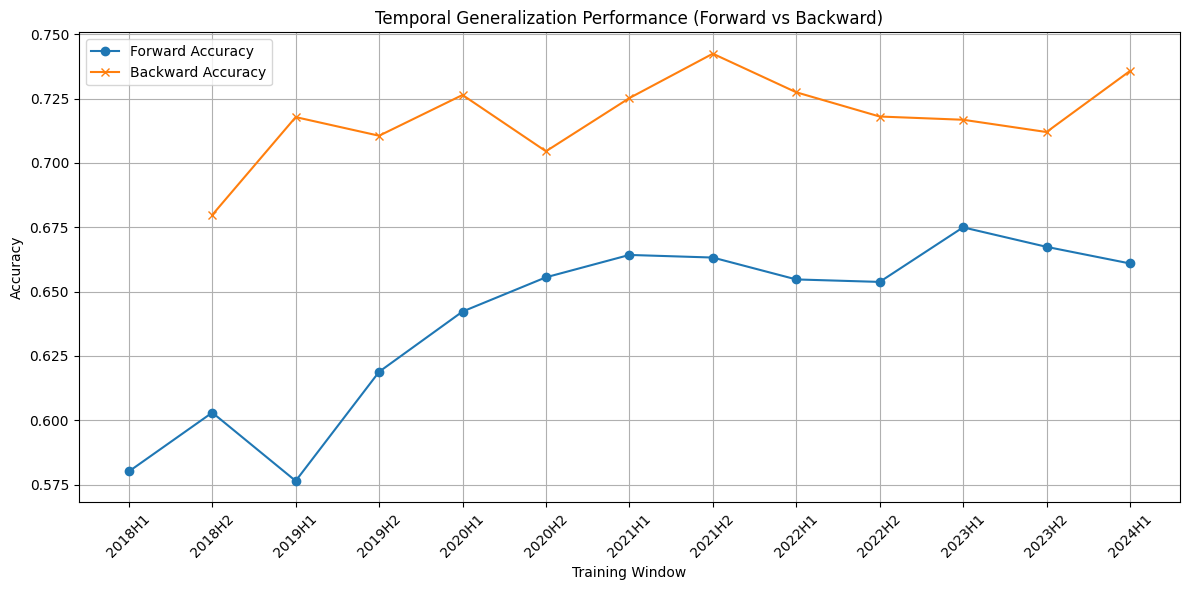

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/phi2_lora_time_models/metrics_log.csv')

forward_df = df[df['direction'] == 'forward']
backward_df = df[df['direction'] == 'backward']

plt.figure(figsize=(12, 6))
plt.plot(forward_df['train_window'], forward_df['accuracy'], label='Forward Accuracy', marker='o')
plt.plot(backward_df['train_window'], backward_df['accuracy'], label='Backward Accuracy', marker='x')
plt.xticks(rotation=45)
plt.grid(True)
plt.xlabel("Training Window")
plt.ylabel("Accuracy")
plt.title("Temporal Generalization Performance (Forward vs Backward)")
plt.legend()
plt.tight_layout()
plt.show()